# CSCI E-83 Graduate Project: Exploring Hospital Readmission Patterns in Diabetic Patients

## Cristina Kennedy, RN, BSN
### November 24, 2025

# Executive Summary
For this project, I wanted to explore a problem within healthcare, which led me to the ever-present issue of patient readmissions. According to the Centers for Medicare & Medicaid Services, a hospital readmission is defined as an unplanned readmission that happens within 30 days from the initial admittance date. As a registered nurse, this topic is close to my heart. I have seen firsthand the impact of patient readmissions on their health outcomes and the impact on the healthcare system as a whole. I am passionate about this topic, as I understand the patient journey and struggles, whether that is health literacy, medication non-adherence, gaps in follow-up care, or social determinants such as finances, housing, and support outside of the hospital walls. 

## Data Sources
Hospital readmissions within 30 days dataset with 25,000 patient records, 17 variables. It contains data gathered over a 10-year period across 130 hospitals. However, the dates and location information is missing, so a tempo-spatial analysis will not be possible for this project.
Data source: https://www.kaggle.com/datasets/dubradave/hospital-readmissions?select=hospital_readmissions.csv

## Problem Statement
The purpose of this project is to conduct a comprehensive exploratory data analysis (EDA) to identify the root causes of hospital readmissions. Since my dataset focuses on patients with diabetes, I aim to investigate how the disease impacts readmissions. Through this project, I seek to explore a few questions, such as:

> * Do patients with diabetes have a higher readmission rate?
> * How the A1C test impacts hospital readmissions.
> * What role does prior healthcare utilization play in hospital readmission?
> * What factors are the biggest drivers of hospital readmission in diabetic patients?


## Data Preparation
I'll begin by importing the required packages and libraries for the analysis, along with my data. 

In [1]:
# Import the required packages

import pandas as pd
import numpy as np
import numpy.random as nr
import io
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from sklearn import metrics
from sklearn.preprocessing import PowerTransformer
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import data
hospital = pd.read_csv('hospital_readmissions.csv')

First, I would like to examine the dataset's structure. I’ll inspect all variables, check how many columns, rows, and observations I have. Next, I’ll check the data types for each column and identify any missing values. Furthermore, let's familiarize ourselves with the variables in the dataset.

### Explanation of variables:¶
* "age" - age bracket of the patient
* "time_in_hospital" - days (from 1 to 14)
* "n_procedures" - number of procedures performed during the hospital stay
* "n_lab_procedures" - number of laboratory procedures performed during the hospital stay
* "n_medications" - number of medications administered during the hospital stay
* "n_outpatient" - number of outpatient visits in the year before a hospital stay
* "n_inpatient" - number of inpatient visits in the year before the hospital stay
* "n_emergency" - number of visits to the emergency room in the year before the hospital stay
* "medical_specialty" - the specialty of the admitting physician
* "diag_1" - primary diagnosis (Circulatory, Respiratory, Digestive, etc.)
* "diag_2" - secondary diagnosis
* "diag_3" - additional secondary diagnosis
* "glucose_test" - whether the glucose serum came out as high (> 200), normal, or not performed
* "A1Ctest" - whether the A1C level of the patient came out as high (> 7%), normal, or not performed
* "change" - whether there was a change in the diabetes medication ('yes' or 'no')
* "diabetes_med" - whether a diabetes medication was prescribed ('yes' or 'no')
* "readmitted" - if the patient was readmitted at the hospital ('yes' or 'no')

In [3]:
# Check shape; visualize the first 5 rows of observations
print(f"Original Shape: {hospital.shape}")
hospital.head(5)

Original Shape: (25000, 17)


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


At first glance, I see that the medical specialty has several missing values. The medical specialty variable is not the most informative for the questions I seek to answer. In the event of a high number of missing values, I am considering excluding it from my analysis.

In [4]:
(hospital['medical_specialty'] == 'Missing').sum()

12382

Next, I want to take a look at the *diag_1*, *diag_2*, and *diag_3*. All these columns capture the presence of diabetes, along with other diagnoses tangential to my research questions and insufficiently documented. That said, I will feature engineer a new column called 'diabetes' that consolidates these columns into a single indicator: diabetes present (1) or absent (0).

In [5]:
hospital['diabetes'] = (
    (hospital['diag_1'] == 'Diabetes') | 
    (hospital['diag_2'] == 'Diabetes') | 
    (hospital['diag_3'] == 'Diabetes')
).astype(int)
hospital['diabetes'] = hospital['diabetes'].map({0: 'no', 1: 'yes'})
# Check results
print(hospital['diabetes'].value_counts())

diabetes
no     16212
yes     8788
Name: count, dtype: int64


Now I will drop the following columns: “medical_specialty”, “diag_1”, “diag_2”, “diag_3”, and check the new dataframe.

In [6]:
hospital.drop(columns=['medical_specialty', 'diag_1', 'diag_2', 'diag_3'], inplace=True)

In [7]:
hospital.head(5)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,glucose_test,A1Ctest,change,diabetes_med,readmitted,diabetes
0,[70-80),8,72,1,18,2,0,0,no,no,no,yes,no,no
1,[70-80),3,34,2,13,0,0,0,no,no,no,yes,no,no
2,[50-60),5,45,0,18,0,0,0,no,no,yes,yes,yes,no
3,[70-80),2,36,0,12,1,0,0,no,no,yes,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,no,no,no,yes,no,no


In [8]:
# Data types
hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               25000 non-null  object
 1   time_in_hospital  25000 non-null  int64 
 2   n_lab_procedures  25000 non-null  int64 
 3   n_procedures      25000 non-null  int64 
 4   n_medications     25000 non-null  int64 
 5   n_outpatient      25000 non-null  int64 
 6   n_inpatient       25000 non-null  int64 
 7   n_emergency       25000 non-null  int64 
 8   glucose_test      25000 non-null  object
 9   A1Ctest           25000 non-null  object
 10  change            25000 non-null  object
 11  diabetes_med      25000 non-null  object
 12  readmitted        25000 non-null  object
 13  diabetes          25000 non-null  object
dtypes: int64(7), object(7)
memory usage: 2.7+ MB


The data frame looks great, and now I can confirm that it contains a mix of numerical and categorical variables. The categorical variables will have to be transformed. Next, I will check for missing values in each column.

In [9]:
print(hospital.isnull().sum())

age                 0
time_in_hospital    0
n_lab_procedures    0
n_procedures        0
n_medications       0
n_outpatient        0
n_inpatient         0
n_emergency         0
glucose_test        0
A1Ctest             0
change              0
diabetes_med        0
readmitted          0
diabetes            0
dtype: int64


I can see that there are no missing values at this point. The next step in getting the data ready for analysis is categorical encoding. I will use pandas' mapping function to transform these categorical variables to numerical values.

In [10]:
# For my binary variables:
binary = {'yes':1, 'no':0}
binary_columns = ['change', 'diabetes_med', 'readmitted', 'diabetes']
for col in binary_columns:
    hospital[col] = hospital[col].map(binary)
    
# For Age 
age_ord = { '[40-50)': 1, '[50-60)': 2, '[60-70)': 3,
            '[70-80)': 4, '[80-90)': 5, '[90-100)': 6
    }
hospital['age'] = hospital['age'].map(age_ord)

# Glucose and A1C tests
glucose = {'no': 0, 'normal': 1, 'high': 2}
hospital['glucose_test'] = hospital['glucose_test'].map(glucose)
a1c = {'no': 0, 'normal': 1, 'high': 2}
hospital['A1Ctest'] = hospital['A1Ctest'].map(a1c)

print(f"New shape: {hospital.shape}")

New shape: (25000, 14)


In [11]:
hospital.head(5)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,glucose_test,A1Ctest,change,diabetes_med,readmitted,diabetes
0,4,8,72,1,18,2,0,0,0,0,0,1,0,0
1,4,3,34,2,13,0,0,0,0,0,0,1,0,0
2,2,5,45,0,18,0,0,0,0,0,1,1,1,0
3,4,2,36,0,12,1,0,0,0,0,1,1,1,1
4,3,1,42,0,7,0,0,0,0,0,0,1,0,0


In [12]:
print(hospital.isnull().sum())

age                 0
time_in_hospital    0
n_lab_procedures    0
n_procedures        0
n_medications       0
n_outpatient        0
n_inpatient         0
n_emergency         0
glucose_test        0
A1Ctest             0
change              0
diabetes_med        0
readmitted          0
diabetes            0
dtype: int64


The data looks great after categorical encoding, and we still have no missing values. Before I move on, I will obtain a summary of the data's statistical properties.

In [13]:
hospital.describe()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,glucose_test,A1Ctest,change,diabetes_med,readmitted,diabetes
count,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,3.344120,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600,0.082440,0.275560,0.460120,0.769120,0.470160,0.351520
std,1.315633,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873,0.361288,0.652536,0.498417,0.421404,0.499119,0.477455
min,1.000000,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,3.000000,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,4.000000,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,6.000000,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


The descriptive statistics reveal that the one-hot-encoded features contain predominantly zeros, indicating the absence of categories, as expected given their binary encoding.

## Data Analysis
The data is ready for analysis. Firstly, I want to understand the proportion of the population that is actually readmitted. I will use countplots for visuals.

It is worth noting at this point that the variable *readmitted* is my target variable, and will remain as such for the rest of the project.

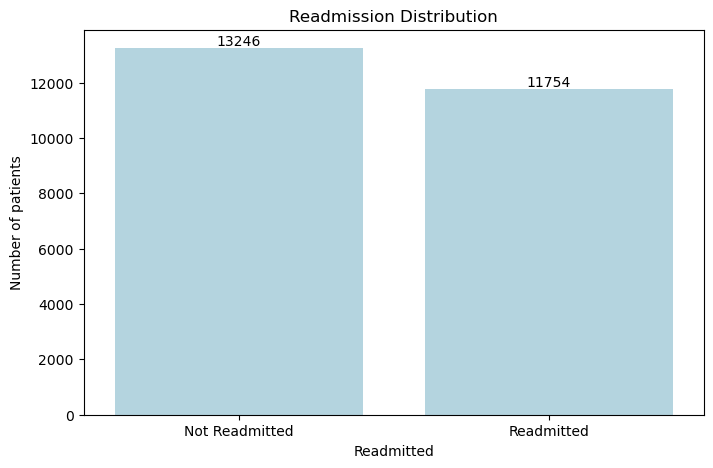

In [14]:
# Bar plot of readmission distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Count plot
sns.countplot(data=hospital, x='readmitted', color='lightblue', ax=ax) # or try with  hue='diabetes'
ax.set_title('Readmission Distribution')
ax.set_xlabel('Readmitted')
ax.set_xticklabels(['Not Readmitted', 'Readmitted'])
ax.set_ylabel('Number of patients')

# Add numbers on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

The good news is that the number of patients readmitted within 30 days is smaller than the number who are not readmitted. The bad news is that the difference is not substantial. A readmission rate of 47% is below optimal. Therefore, we need to identify the primary drivers of readmission so hospitals and clinicians across the board can shift their efforts toward proactive care!



### Multivariate Analysis: Correlation Matrix¶
According to GeekforGeeks (2023), correlation analysis is a statistical technique for determining the strength of a link between two variables. The goal is to visually assess the relationship between all my variables. In the event of high correlation, I will have to address them before using them in any of teh later models. Below is the correlation matrix for the hospital data.

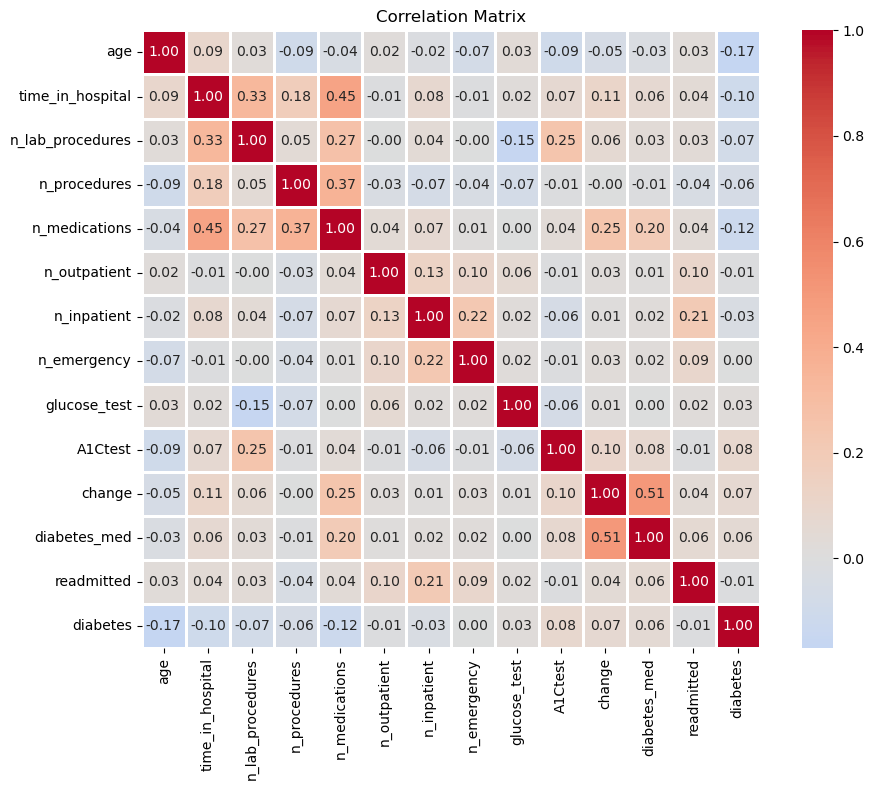

In [15]:
# Create correlation matrix
corr_matrix = hospital.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Overall, there is a weak correlation between the target variable *readmitted* and the other variables, with the strongest being *n_inpatient* (0.21). 

There is a correlation among the remaining variables, but it is not very strong. The strongest link is between *change* and *diabetes_med* (0.51), followed by *n_medications* and *time_in_hospital*.

There is no substantial evidence of multicollinearity, which is great news. However, the weak linear relationship between individual features and readmission is not ideal. Overall, these results make sense and validate some of my earlier findings. These results reinforce the use of logistic regression as an appropriate baseline model.

### Bivariate Analysis
I would like to address the findings in the correlation matrix. First, let’s look at the relationship between *change* and *diabetes_med*, in the context of the target variable *readmitted*. Since both variables are binary, creating FacetGrids is appropriate.

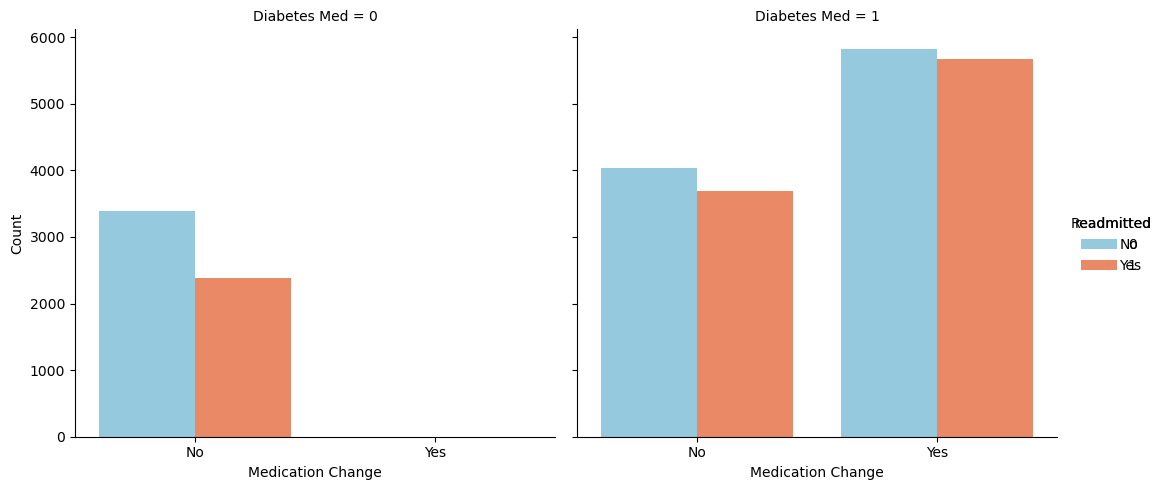

In [16]:
g = sns.catplot(data=hospital, x='change', hue='readmitted', col='diabetes_med',
                kind='count', palette=['skyblue', 'coral'], height=5, aspect=1)
g.set_axis_labels('Medication Change', 'Count')
g.set_titles('Diabetes Med = {col_name}')
g.set_xticklabels(['No', 'Yes'])
g.add_legend(title='Readmitted', labels=['No', 'Yes'])
plt.show()

For interpretation:
* 0 = Not on diabetes medication
* 1 = On diabetes medication

We see that there is a higher number of patients readmitted who have changes in medication and are on diabetes medication. This is unsurprising, as diabetes typically does not present as a standalone disease. However, I am surprised that medication changes did not improve readmission rates. The group with the lowest readmission rate comprises patients who have not had any medication changes and are not taking diabetes medications. Essentially, medication changes don't improve readmission rates.

Next, let's explore the relationship between *n_medications* and *time_in_hospital*. To this end, I will use conditioning plotting.

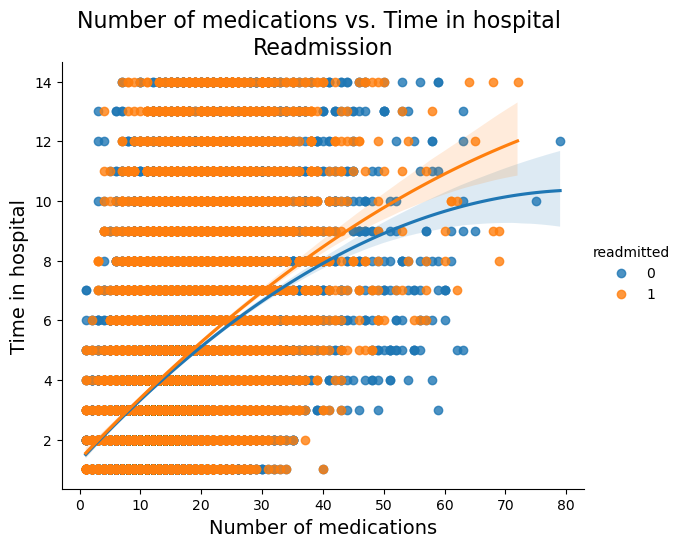

In [17]:
g = sns.lmplot(x = 'n_medications', y = 'time_in_hospital', 
                      hue = 'readmitted',
                      order=2,
                      aspect=1.2,
                      height=5,
                      data=hospital)
plt.title('Number of medications vs. Time in hospital \nReadmission', fontsize=16);
plt.xlabel('Number of medications', fontsize=14);
plt.ylabel('Time in hospital', fontsize=14); 

As seen on the correlation matrix, the number of medications and the length of hospital stay are strongly positively associated. The more medications a patient has, the greater the risk of readmission.


To answer some of my initial questions, I would like to examine how A1C test results relate to readmissions. The A1C test is a blood test that provides information about your average blood glucose levels over the past 3 months. The A1C test can be used to diagnose type 2 diabetes and prediabetes. The A1C test is also the primary test used for diabetes management (NIDDK, 2018). In my experience, A1C is a significant indicator of glycemic control in diabetes. I am interested in how the readmission rate among patients with high A1C compares with that among patients with normal A1C.

I will perform this using the pandas cross-tabulation method.

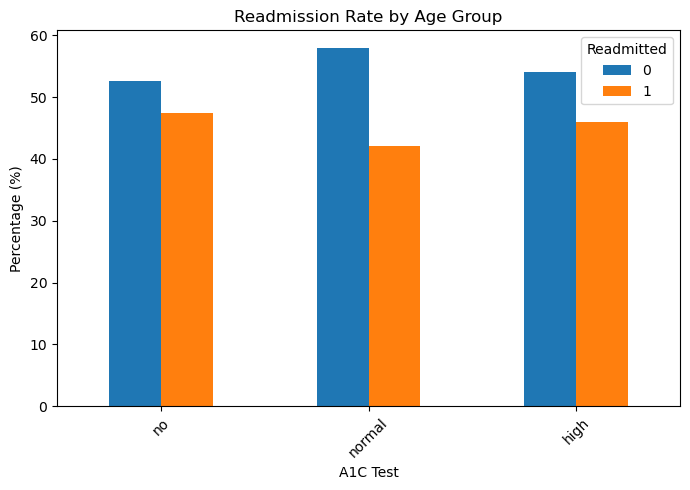

In [18]:
# Create cross-tabulation
age_readmit = pd.crosstab(hospital['A1Ctest'], hospital['readmitted'], normalize='index') * 100

# Plot
age_readmit.plot(kind='bar', stacked=False, figsize=(7, 5))
plt.title('Readmission Rate by Age Group')
plt.xlabel('A1C Test')
plt.xticks(ticks=[0, 1, 2], 
           labels=['no', 'normal', 'high'])
plt.ylabel('Percentage (%)')
plt.legend(title='Readmitted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Although a fair number of people did not receive the A1C test, high A1C results are associated with higher readmission rates than normal results.


## Further bivariate analysis
### Data distribution and outliers

To further explore how the remaining features differ between readmitted and non-readmitted patients, I created boxplots for all variables to assess their distributions and identify any extreme values. It will give me a good insight into the data’s distribution and potential outliers.

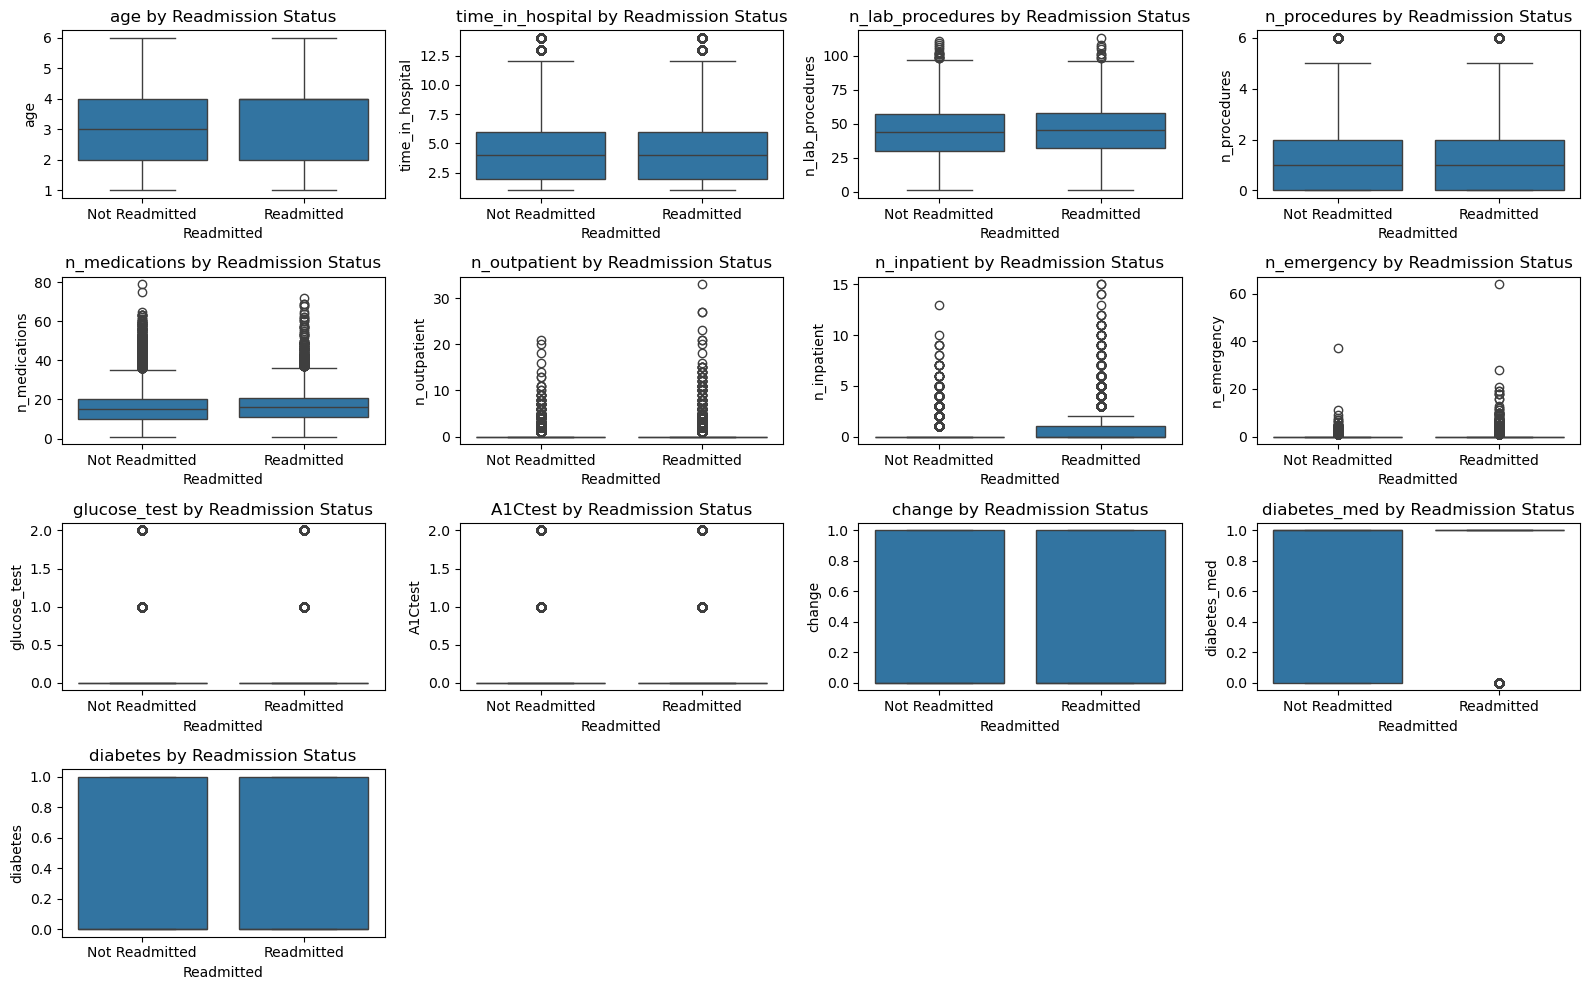

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
axes = axes.flatten()

vars = ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 
        'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'glucose_test', 
        'A1Ctest', 'change', 'diabetes_med', 'diabetes']

for idx, var in enumerate(vars):
    sns.boxplot(data=hospital, x='readmitted', y=var, ax=axes[idx])
    axes[idx].set_title(f'{var} by Readmission Status')
    axes[idx].set_xlabel('Readmitted')
    axes[idx].set_xticklabels(['Not Readmitted', 'Readmitted'])

# Hide extra subplots
axes[-1].axis('off')
axes[-2].axis('off')
axes[-3].axis('off')
plt.tight_layout()
plt.show()

The boxplots highlight essential information and patterns in the data. It is noticeabale that the number of inpatient visits has a strong predictive power. I am interested in exploring this variable more, along with the number of lab procedures, medications, outpatient visits, time in teh hospital, and emergency visits. Several variables show a high number of outliers. I recognize these as real, high-risk patients. Medical complexity tends to increase healthcare utilization, as evidenced by the number of emergency visits and the inpatient population. This being said, I choose not to eliminate the outliers at this time, as they are relevant to my data analysis. 

A lot of my numerical variables show similar distributions between readmitted and non-readmitted patients.

To further explore the relationships between the target variable and the variables noted above, I will compute pair plots with kernel density estimates. For instance,* n_inpatient* and *n_emergency* show a clear difference between readmitted and non-readmitted groups. 
Furthermore, *n_medications*, *time_in_hospital*, and *n_lab_procedures* all show differences that warrant further examination. 


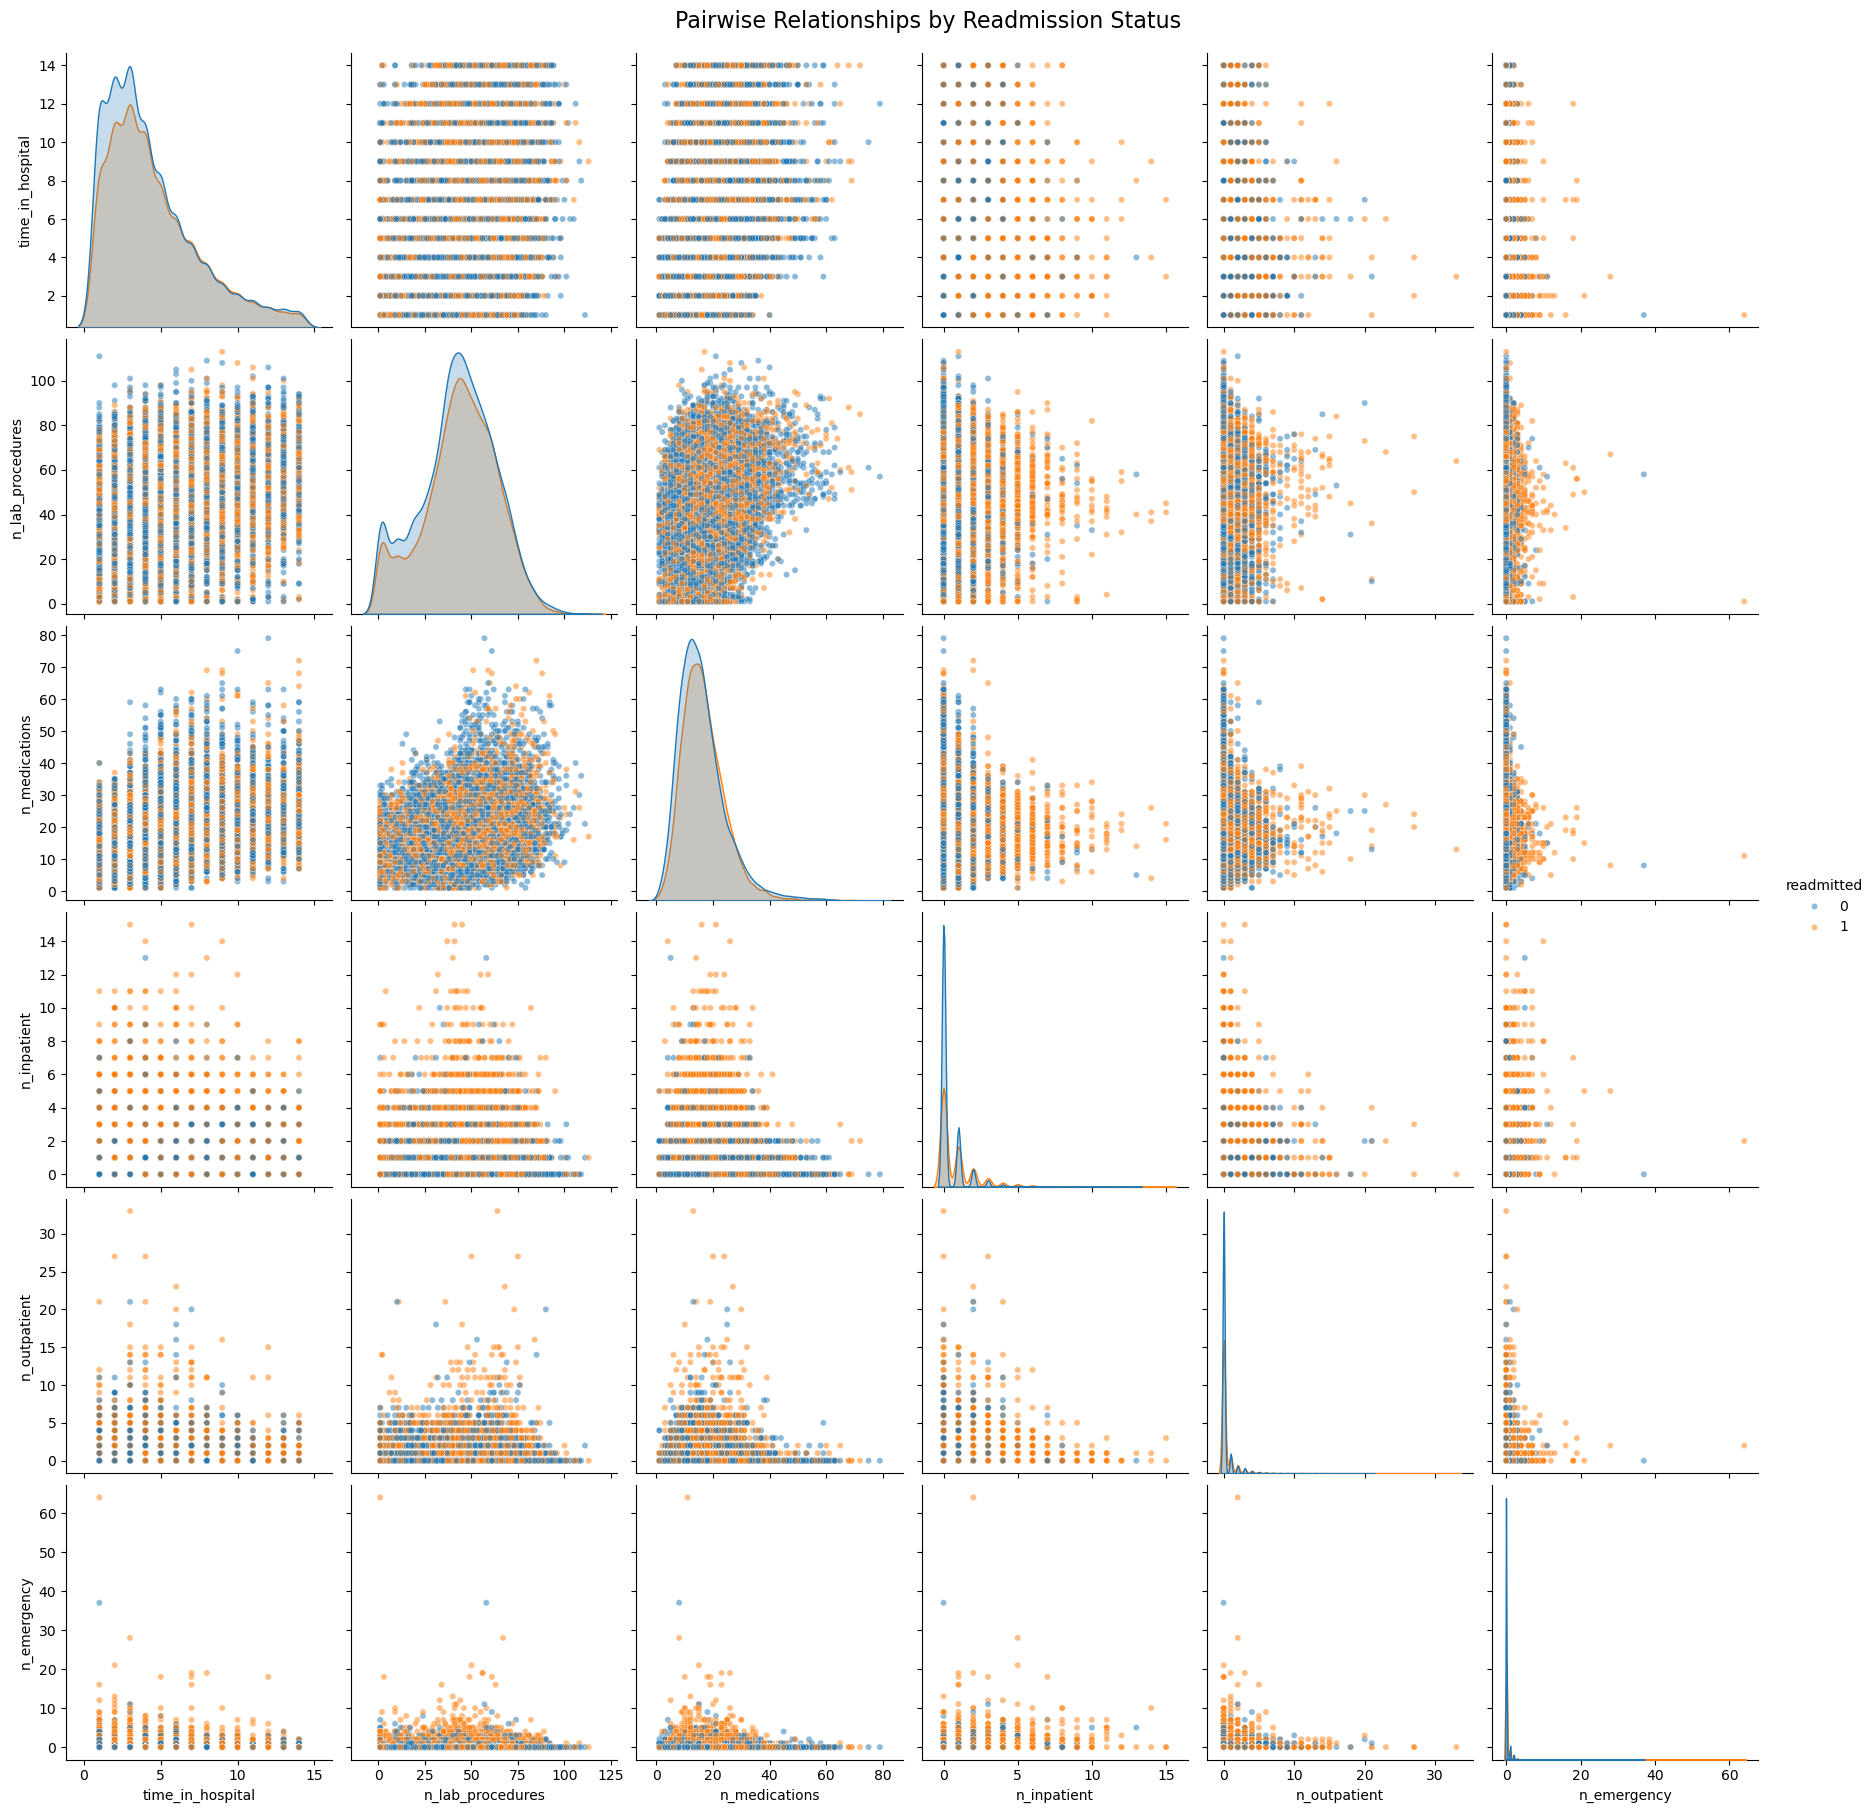

In [20]:
# Variables to be analyzed
vars = ['time_in_hospital', 'n_lab_procedures', 
        'n_medications', 'n_inpatient', 'n_outpatient', 'n_emergency']
g = sns.pairplot(hospital[vars + ['readmitted']], 
                 hue='readmitted',
                 diag_kind='kde', 
                 plot_kws={'alpha': 0.5, 's': 20},
                 height=3)
g.fig.suptitle('Pairwise Relationships by Readmission Status', 
               y=1.01, fontsize=16)
plt.show()

One of the first things I notice is the pronounced right skew in most of my variables. This suggests that they require transformation. Since my data contains both positive and zero values, I applied a Yeo-Johnson transformation.

In [21]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Transform all variables at once
vars_yj = pt.fit_transform(hospital[vars])

# Add transformed columns to dataframe
for i, var in enumerate(vars):
    hospital[f'{var}_yj'] = vars_yj[:, i]
    # print(f"Created {var}_yj (lambda={pt.lambdas_[i]:.4f})")

In [22]:
hospital.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,glucose_test,A1Ctest,change,diabetes_med,readmitted,diabetes,time_in_hospital_yj,n_lab_procedures_yj,n_medications_yj,n_inpatient_yj,n_outpatient_yj,n_emergency_yj
0,4,8,72,1,18,2,0,0,0,0,0,1,0,0,1.195512,1.453146,0.379976,-0.710632,2.269457,-0.349979
1,4,3,34,2,13,0,0,0,0,0,0,1,0,0,-0.297491,-0.467777,-0.278401,-0.710632,-0.445530,-0.349979
2,2,5,45,0,18,0,0,0,0,0,1,1,1,0,0.458517,0.087545,0.379976,-0.710632,-0.445530,-0.349979
3,4,2,36,0,12,1,0,0,0,0,1,1,1,1,-0.845687,-0.366866,-0.430064,-0.710632,2.215947,-0.349979
4,3,1,42,0,7,0,0,0,0,0,0,1,0,0,-1.635342,-0.063979,-1.351233,-0.710632,-0.445530,-0.349979


Now that the variables have been transformed and verified, they have been added to the data frame, let's examine what the distributions look like.

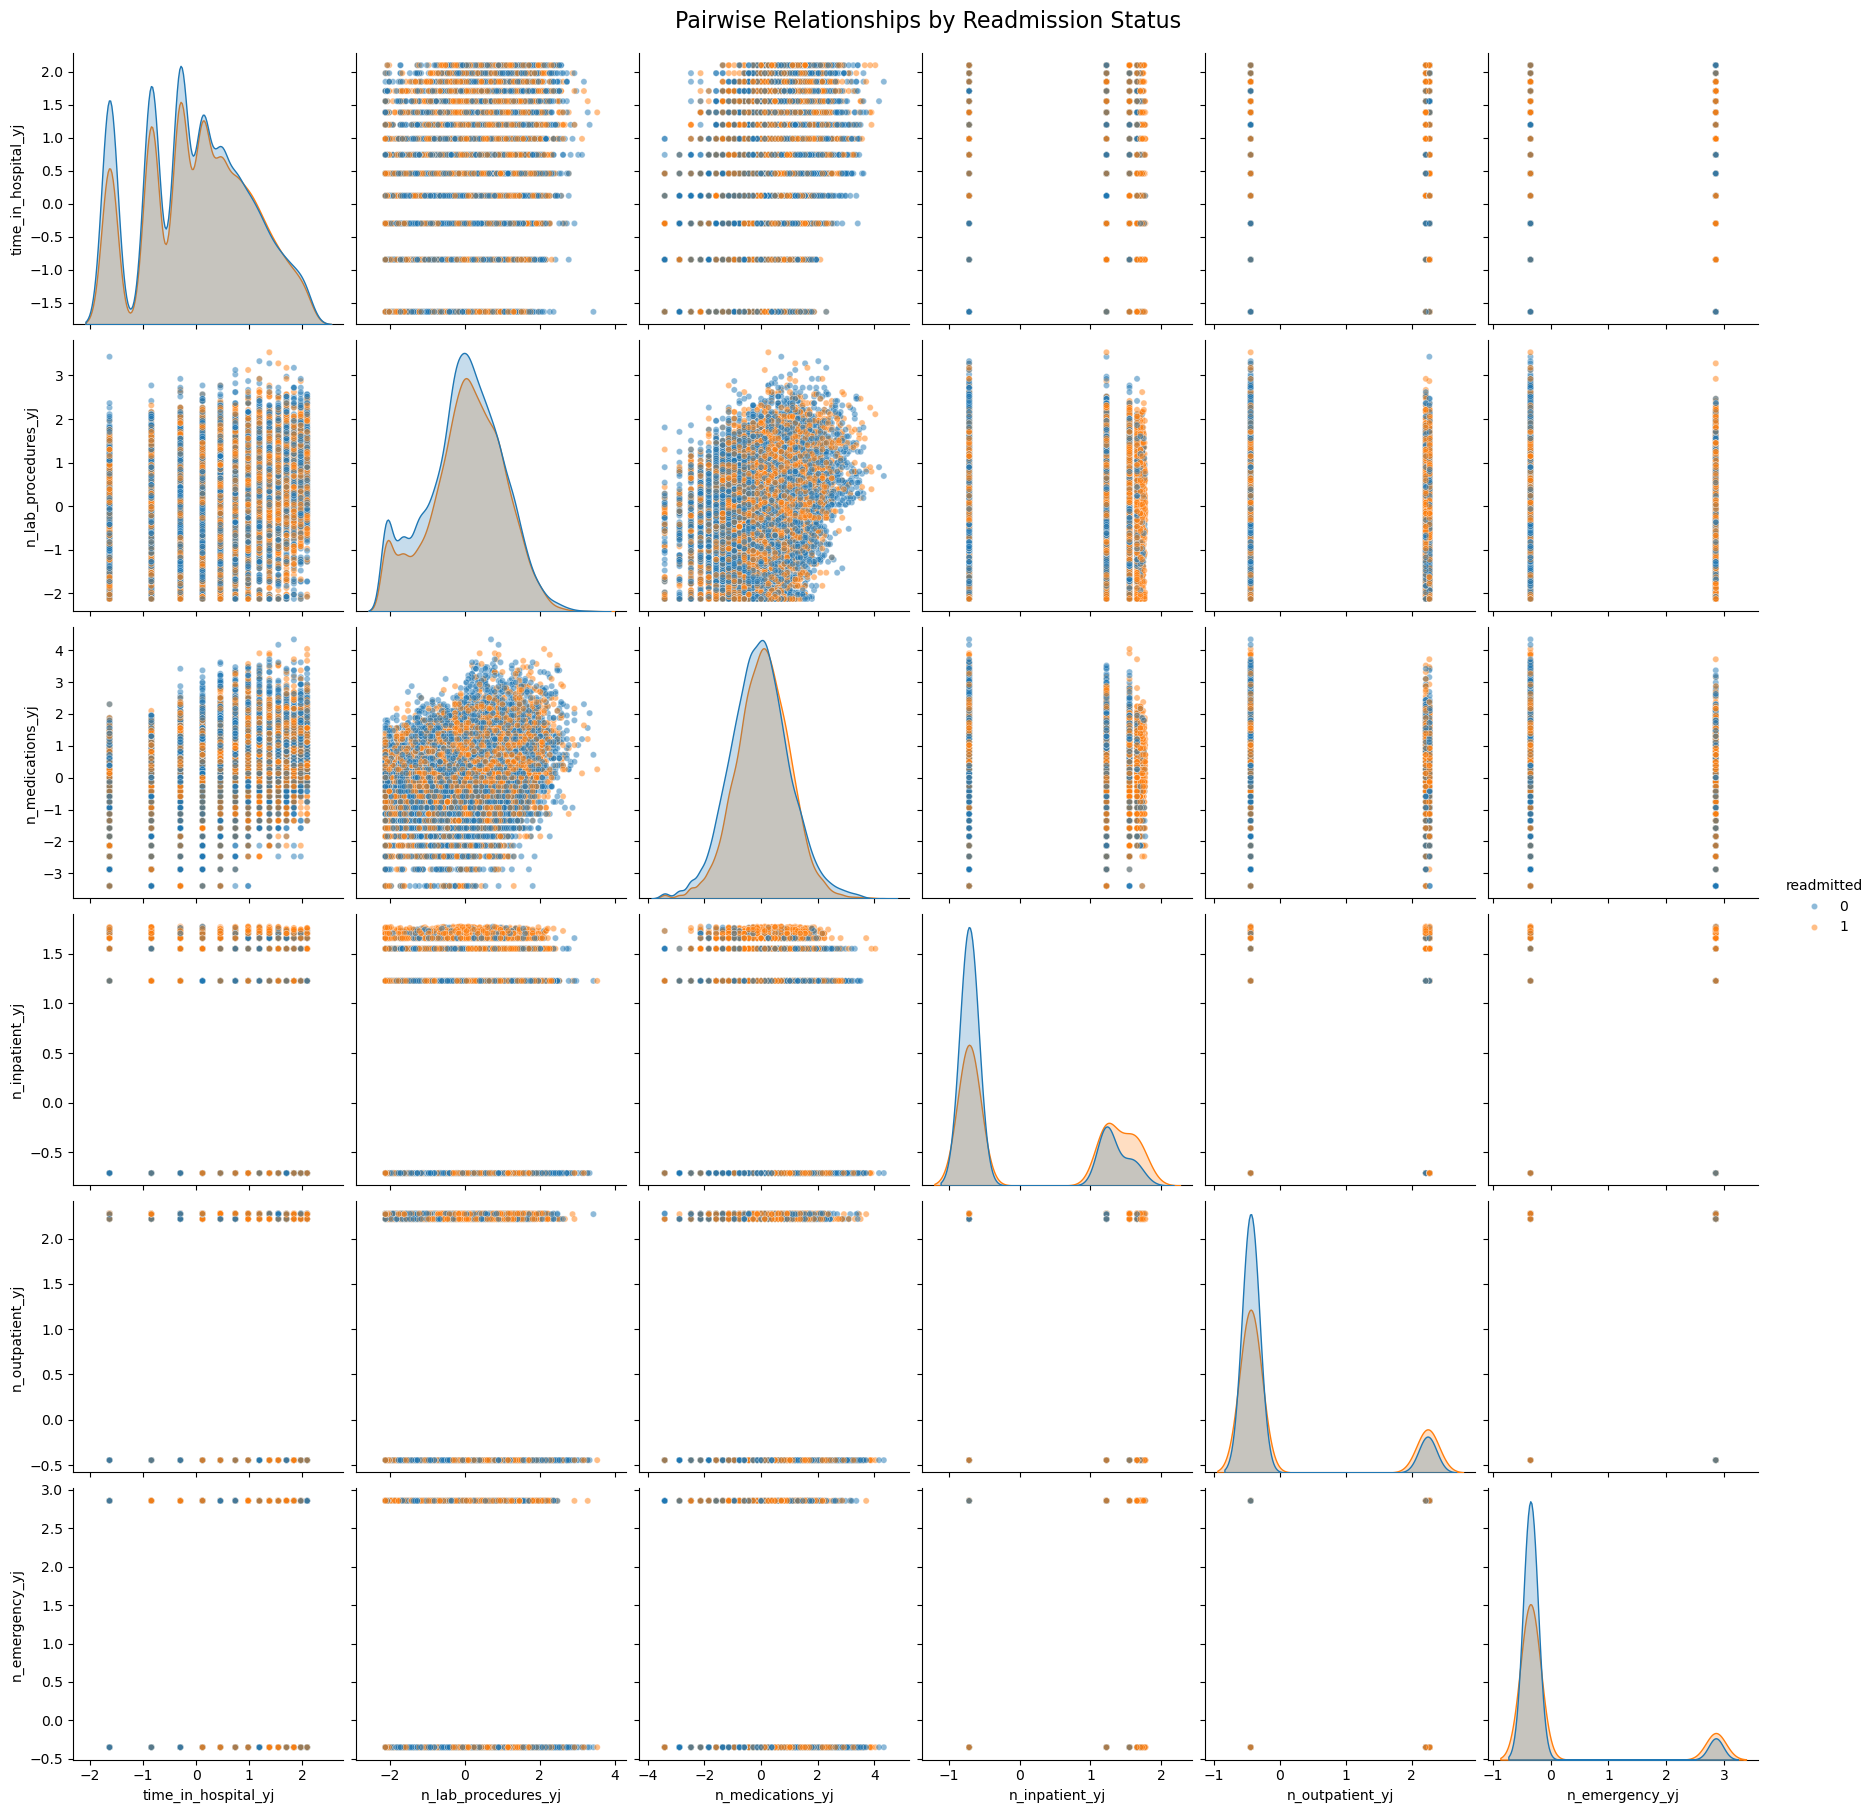

In [23]:
vars_transformed = ['time_in_hospital_yj', 'n_lab_procedures_yj', 
        'n_medications_yj', 'n_inpatient_yj', 'n_outpatient_yj', 'n_emergency_yj']
g = sns.pairplot(data=hospital, 
                 vars=vars_transformed, 
                 hue='readmitted',
                 diag_kind='kde',  # Density plots on diagonal
                 plot_kws={'alpha': 0.5, 's': 20},
                 height=3)
g.fig.suptitle('Pairwise Relationships by Readmission Status', 
               y=1.01, fontsize=16)
plt.show()

The Yeo-Johnson transformation has worked well. The KDE plots for all my variables appear more normal, and skewness has decreased. Furthermore, I can extract information that was previously hard to access. For instance, we observe the multimodal distribution of time_in_hospital_yj. This pattern is unsurprising, as hospital admissions typically occur at intervals of 1-3 days, 5-7 days, or 10-14 days. Variables *n_emergency_yj*, *n_outpatient_yj*, and* n_inpatient_yj* exhibit clear bimodal distributions.

I am now ready to proceed to the data modeling phase.

# Data Modeling

Given that my problem is essentially a binary classification with two outcomes (readmitted/not readmitted), I will use a logistic regression with all original variables as the base model.

### Logistic regression with original variables.

In [24]:
## Create a mask and use it to split the data into a train and test set  
frac = 0.6
nr.seed(665)
mask = nr.choice(hospital.index, size = int(frac * hospital.shape[0]), replace=False)
hospital_train = hospital.iloc[mask,:]
hospital_test = hospital.drop(mask, axis=0)         
hospital_train.columns

Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted',
       'diabetes', 'time_in_hospital_yj', 'n_lab_procedures_yj',
       'n_medications_yj', 'n_inpatient_yj', 'n_outpatient_yj',
       'n_emergency_yj'],
      dtype='object')

In [25]:
# Compile and fit model
formula = 'readmitted ~ age + time_in_hospital + n_lab_procedures + n_procedures + n_medications + n_outpatient + n_inpatient + n_emergency + glucose_test + A1Ctest + change + diabetes_med + diabetes'
hospital_glm = smf.glm(formula=formula, data=hospital_train, family=sm.families.Binomial()).fit()
hospital_glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:             readmitted   No. Observations:                15000
Model:                            GLM   Df Residuals:                    14986
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9893.0
Date:                Fri, 19 Dec 2025   Deviance:                       19786.
Time:                        16:05:52   Pearson chi2:                 1.52e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06107
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.8747      0.075    -11.587      0.000      -1.023      -0.727
age                  0.0405      0.013      3.044      0.002       0.014       0.067
time_in_hospital     0.0115      0.007      1.745      0.081      -0.001       0.024
n_lab_procedures     0.0019      0.001      1.957      0.050   -2.59e-06       0.004
n_procedures        -0.0417      0.011     -3.819      0.000      -0.063      -0.020
n_medications        0.0023      0.003      0.898      0.369      -0.003       0.007
n_outpatient         0.1226      0.017      7.068      0.000       0.089       0.157
n_inpatient          0.3897      0.019     20.727      0.000       0.353       0.427
n_emergency          0.2023      0.032      6.253      0.000       0.139       0.266
glucose_test         0.0758      0.048      1.593      0.111      -0.017       0.169
A1Ctest             -0.0582      0.027     -2.134      0.033      -0.112      -0.005
change               0.0394      0.040      0.985      0.325      -0.039       0.118
diabetes_med         0.2284      0.047      4.863      0.000       0.136       0.320
diabetes             0.0377      0.037      1.031      0.303      -0.034       0.109
====================================================================================
"""

This model is not ideal. We have a very low pseudo R-squared and a high deviance. According to this model, the significant variables are those related to prior hospitalization, such as n_inpatient, n_outpatient, and n_emergency, as well as diabetes_med and age.

Now, let’s examine the readmission probabilities.

In [26]:
def display_metrics(hospital_test, threshold):
    print('\n\nPrediction of being readmitted:')
    print(hospital_test.loc[:5,'predicted'])
    
    print('\nConfusion Matrix')
    Confusion_Matrix = metrics.confusion_matrix(hospital_test.loc[:,'readmitted'], hospital_test.loc[:,'predicted'])
    accuracy = metrics.accuracy_score(hospital_test.loc[:,'readmitted'], hospital_test.loc[:,'predicted'])
    precision = metrics.precision_score(hospital_test.loc[:,'readmitted'], hospital_test.loc[:,'predicted'])
    recall = metrics.recall_score(hospital_test.loc[:,'readmitted'], hospital_test.loc[:,'predicted'])
    Confusion_Matrix = pd.DataFrame(Confusion_Matrix, index=['True No Readmission', 'True Readmission'], columns = ['Predicted No Readmission', 'Predicted Readmission'])
    print(Confusion_Matrix)
    print(f"\nAccuracy = {round(accuracy, 3)}")
    print(f"Precision = {round(precision, 3)}")
    print(f"Recall = {round(recall, 3)}")

threshold = 0.4
hospital_test.loc[:,'predicted_prob'] = hospital_glm.predict(hospital_test)
hospital_test.loc[:,'predicted'] = np.where(hospital_test.loc[:,'predicted_prob'] > threshold, 1, 0)
display_metrics(hospital_test, threshold)



Prediction of being readmitted:
0    1
2    1
3    1
Name: predicted, dtype: int64

Confusion Matrix
                     Predicted No Readmission  Predicted Readmission
True No Readmission                      2031                   3228
True Readmission                         1037                   3704

Accuracy = 0.574
Precision = 0.534
Recall = 0.781


These results are not fantastic, but I appreciate the higher recall. When considering problems in medicine, such as predicting readmission rates, higher recall is more important than higher precision, as recall measures the proportion of actual positive cases (i.e., readmitted patients) correctly identified. 

## Logistic Regression with tranformed variables

In [27]:
# Compile and fit model
formula_transformed = 'readmitted ~ age + time_in_hospital_yj + n_lab_procedures_yj + n_medications_yj + n_outpatient + n_inpatient_yj + n_emergency_yj+ glucose_test + A1Ctest + change + diabetes_med + diabetes'
hospital_glm_tr = smf.glm(formula=formula_transformed, data=hospital_train, family=sm.families.Binomial()).fit()
hospital_glm_tr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:             readmitted   No. Observations:                15000
Model:                            GLM   Df Residuals:                    14987
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9932.8
Date:                Fri, 19 Dec 2025   Deviance:                       19866.
Time:                        16:05:53   Pearson chi2:                 1.50e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05607
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.4831      0.060     -8.000      0.000      -0.601      -0.365
age                     0.0345      0.013      2.617      0.009       0.009       0.060
time_in_hospital_yj     0.0414      0.020      2.080      0.038       0.002       0.080
n_lab_procedures_yj     0.0312      0.019      1.640      0.101      -0.006       0.069
n_medications_yj        0.0216      0.020      1.073      0.283      -0.018       0.061
n_outpatient            0.1269      0.017      7.349      0.000       0.093       0.161
n_inpatient_yj          0.3872      0.017     22.220      0.000       0.353       0.421
n_emergency_yj          0.1100      0.018      6.208      0.000       0.075       0.145
glucose_test            0.0825      0.047      1.739      0.082      -0.010       0.175
A1Ctest                -0.0493      0.027     -1.809      0.070      -0.103       0.004
change                  0.0267      0.040      0.670      0.503      -0.051       0.105
diabetes_med            0.2207      0.047      4.704      0.000       0.129       0.313
diabetes                0.0606      0.037      1.656      0.098      -0.011       0.132
=======================================================================================
"""

In [28]:
hospital_test.loc[:,'predicted_prob'] = hospital_glm_tr.predict(hospital_test)
hospital_test.loc[:,'predicted'] = np.where(hospital_test.loc[:,'predicted_prob'] > threshold, 1, 0)
display_metrics(hospital_test, threshold)



Prediction of being readmitted:
0    1
2    0
3    1
Name: predicted, dtype: int64

Confusion Matrix
                     Predicted No Readmission  Predicted Readmission
True No Readmission                      2570                   2689
True Readmission                         1433                   3308

Accuracy = 0.588
Precision = 0.552
Recall = 0.698


Overall, the model improved slightly, but not substantially. What we gained in accuracy and precision, we lost in recall. However, this is still a severely underfit model. R-squared is even lower than in the original model, and the chi-squared and deviance are really high. This indicates there is a problem with my features/data.

To improve the model, I will use elastic net regularization for automatic feature selection.

# L1 Regularization

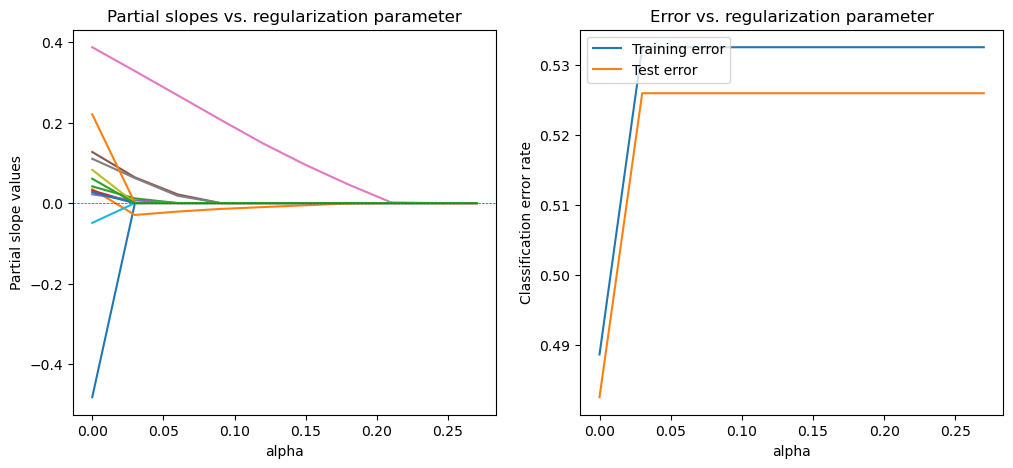

In [29]:
def regularized_coefs_glm(df_train, df_test, alphas, L1_wt=0.5, n_coefs=12,
                      formula = formula, label='readmitted', threshold = 0.35):
    '''Function that computes a linear model for each value of the regularization 
    parameter alpha and returns an array of the coefficient values. The L1_wt 
    determines the trade-off between L1 and L2 regualarization'''
    coefs = np.zeros((len(alphas),n_coefs + 1))
    err_train = []
    err_test = []
    for i,alpha in enumerate(alphas):
        ## First compute the training MSE
        #### Complete the line of code below
        temp_mod = smf.glm(formula, data=df_train, family=sm.families.Binomial()).fit_regularized(alpha=alpha,L1_wt=L1_wt)
        
        ## Save the model coefficeints
        coefs[i,:] = temp_mod.params
        ## Compute training error 
        err_train.append(np.sum(np.abs(df_train.loc[:,label] - np.where(temp_mod.predict(df_train) > threshold, 1, 0)))/float(len(df_train)))
        ## Then compute the test error
        err_test.append(np.sum(np.abs(df_test.loc[:,label] - np.where(temp_mod.predict(df_test) > threshold, 1, 0)))/float(len(df_test)))        
    return coefs, err_train, err_test

def plot_coefs(coefs, alphas, err_train, err_test, ylim=None, \
               title='Error vs. regularization parameter number',\
               ylab='Root mean squared error', location='lower right'):
    fig, ax = plt.subplots(1,2, figsize=(12, 5)) # define axis
    for i in range(coefs.shape[1]): # Iterate over coefficients
        ax[0].plot(alphas, coefs[:,i])
    ax[0].axhline(0.0, color='red', linestyle='--', linewidth=0.5)
    ax[0].set_ylabel('Partial slope values')
    ax[0].set_xlabel('alpha')
    ax[0].set_title('Partial slopes vs. regularization parameter')
    if ylim is not None: ax[0].set_ylim(ylim)
    
    ax[1].plot(alphas, err_train, label='Training error')
    ax[1].plot(alphas, err_test, label='Test error')
    ax[1].set_ylabel(ylab)
    ax[1].set_xlabel('alpha')
    ax[1].set_title(title)
    plt.legend(loc=location)
    plt.show()
    
alphas = np.arange(0.0, 0.3, step = 0.03)
Betas, err_train, err_test = regularized_coefs_glm(hospital_train, hospital_test, alphas, L1_wt=0.5, formula=formula_transformed)

plot_coefs(Betas, alphas, err_train, err_test, title='Error vs. regularization parameter',\
           ylab='Classification error rate', location='upper left')

In [30]:
hospital_glm_elastic = smf.glm(formula=formula, data=hospital_train, family=sm.families.Binomial()).fit_regularized(alpha=0.025,L1_wt=0.5)

def print_coefficient_comparision(mod, compare_mod):
    df = pd.DataFrame(compare_mod.params)
    # Correct the transformed index names
    series = pd.DataFrame(mod.params)
    series = series.rename({
        'n_lab_procedures_yj': 'n_lab_procedures',
        'time_in_hospital_yj': 'time_in_hospital',
        'n_emergency_yj': 'n_emergency',
        'n_medications_yj': 'n_medications',
        'n_inpatient_yj': 'n_inpatient',
        
    })
    df = pd.concat([df, series], axis=1)
    df = df.dropna()
    df.columns = ['Compare model','Model']                
    print(df)
    comp_mag = np.linalg.norm(df.loc[:,'Compare model'])
    mag = np.linalg.norm(df.loc[:,'Model'])
    df.drop('Intercept', axis=0, inplace=True)
    comp_mag_nointercept = np.linalg.norm(df.loc[:,'Compare model'])
    mag_nointercept = np.linalg.norm(df.loc[:,'Model'])

    print('\nMagnitude of base model = {0:4.2f}  Without intercept = {1:4.2f}'.format(comp_mag, comp_mag_nointercept))
    print('Magnitude of new model = {0:4.2f}  Without intercept = {1:4.2f}'.format(mag, mag_nointercept))

print_coefficient_comparision(hospital_glm_elastic, hospital_glm)


                  Compare model     Model
Intercept             -0.874702  0.000000
age                    0.040511 -0.030076
time_in_hospital       0.011477  0.000000
n_lab_procedures       0.001878 -0.003044
n_procedures          -0.041655 -0.048668
n_medications          0.002344  0.000000
n_outpatient           0.122572  0.072313
n_inpatient            0.389673  0.317666
n_emergency            0.202337  0.045882
glucose_test           0.075767  0.000000
A1Ctest               -0.058209  0.000000
change                 0.039418  0.000000
diabetes_med           0.228383  0.000000
diabetes               0.037735  0.000000

Magnitude of base model = 1.02  Without intercept = 0.52
Magnitude of new model = 0.33  Without intercept = 0.33


In [31]:
threshold = 0.42
hospital_test.loc[:,'predicted_prob'] = hospital_glm_elastic.predict(hospital_test)
hospital_test.loc[:,'predicted'] = np.where(hospital_test.loc[:,'predicted_prob'] > threshold, 1, 0)
display_metrics(hospital_test, threshold)



Prediction of being readmitted:
0    1
2    1
3    1
Name: predicted, dtype: int64

Confusion Matrix
                     Predicted No Readmission  Predicted Readmission
True No Readmission                      1342                   3917
True Readmission                          870                   3871

Accuracy = 0.521
Precision = 0.497
Recall = 0.816


The regularization has improved the recall, but the accuracy and precision are pretty low. I was hoping that the elastic net will improve model generalization. It is not very surprising, as elastic net works better to treat overfitting rather than underfitting. The good news is that through regularization we've identified the most relevant predictors.  

Next, I will compile a generalized linear model to test if we see any model improvemt.

In [32]:
formula_transformed = 'readmitted ~ age + n_lab_procedures_yj + n_outpatient_yj + n_inpatient_yj + n_emergency_yj'
hospital_glm_tr = smf.glm(formula=formula_transformed, data=hospital_train, family=sm.families.Binomial()).fit()
hospital_glm_tr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:             readmitted   No. Observations:                15000
Model:                            GLM   Df Residuals:                    14994
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9952.7
Date:                Fri, 19 Dec 2025   Deviance:                       19905.
Time:                        16:05:55   Pearson chi2:                 1.50e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05356
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.2368      0.046     -5.135      0.000      -0.327      -0.146
age                     0.0334      0.013      2.606      0.009       0.008       0.058
n_lab_procedures_yj     0.0447      0.017      2.650      0.008       0.012       0.078
n_outpatient_yj         0.1579      0.017      9.073      0.000       0.124       0.192
n_inpatient_yj          0.3893      0.017     22.487      0.000       0.355       0.423
n_emergency_yj          0.1080      0.018      6.093      0.000       0.073       0.143
=======================================================================================
"""

Unfortunately, the model still has very low predictive power. My next step is to fit a generalized linear model with a Poisson distribution. However, because the Poisson GLM requires an integer count as the target variable, I will address another question: What is the relationship among the number of medications, age, and other healthcare utilization variables?

## Poisson GLM

In [35]:
poisson_formula = 'n_medications ~ time_in_hospital + n_inpatient +n_emergency'
poisson_glm = smf.glm(formula=poisson_formula, data=hospital_train, family=sm.families.Poisson()).fit()
poisson_glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:          n_medications   No. Observations:                15000
Model:                            GLM   Df Residuals:                    14996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -56324.
Date:                Fri, 19 Dec 2025   Deviance:                       44915.
Time:                        16:09:19   Pearson chi2:                 4.68e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5338
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.4617      0.004    645.215      0.000       2.454       2.469
time_in_hospital     0.0668      0.001    109.369      0.000       0.066       0.068
n_inpatient          0.0116      0.002      6.780      0.000       0.008       0.015
n_emergency          0.0057      0.002      2.537      0.011       0.001       0.010
====================================================================================
"""

These results are decent. This model achieves a predictive power of 53%, which is substantially higher than that of my previous models. All the variables are significant. The number of medications can be easier to predict than the number of readmissions.

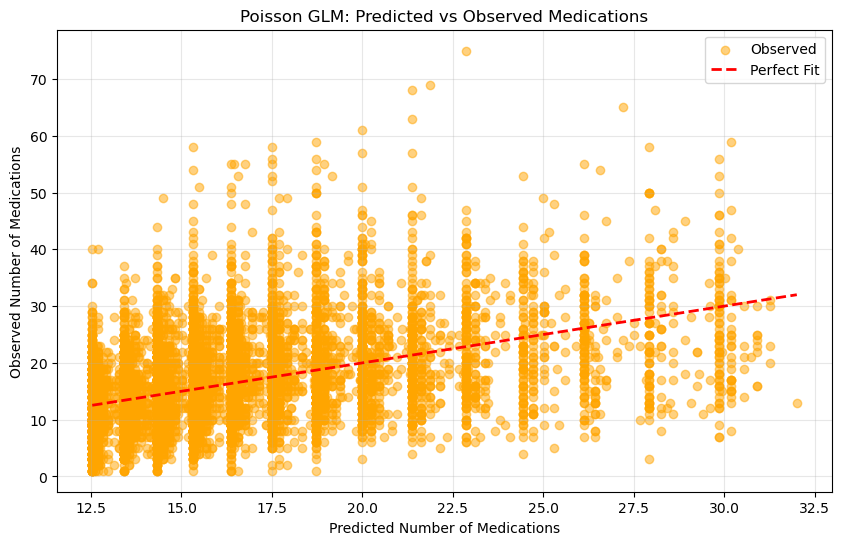

In [37]:
# Get predictions
y_pred = poisson_glm.predict(hospital_test)
y_actual = hospital_test['n_medications']

# ============================================
# Option 1: Scatter plot (Observed vs Predicted)
# ============================================
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y_actual, color='orange', alpha=0.5, label='Observed')
plt.plot([y_pred.min(), y_pred.max()], 
         [y_pred.min(), y_pred.max()], 
         color='red', linestyle='--', linewidth=2, label='Perfect Fit')
plt.xlabel('Predicted Number of Medications')
plt.ylabel('Observed Number of Medications')
plt.title('Poisson GLM: Predicted vs Observed Medications')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Despite the model's high predictive power, it consistently underestimates the number of medications and therefore cannot be used as a reliable source. I believe the model struggles because the data exhibit considerable overdispersion, so I may need a different approach, such as a negative binomial regression. Poisson assumes the variance equals the mean, which is clearly not the case here. A negative binomial regression allows for more flexibility in allowing the variance to be higher than the mean. 

## Conclusion

For this project, I explored hospital readmissions in patients with diabetes. Before starting the data exploration, I expected that variables such as age, A1C test results, diabetes status, and secondary diagnosis would be the main drivers of readmission. However, I now understand that variables related to hospital utilization, such as the number of procedures performed, inpatient stay, number of medications, and emergency status, have the greatest influence on readmission risk.  

For data modeling, I opted to use generalized linear models (GLM), as they are widely used in healthcare for their interpretability and are well-suited to the binary nature of my target variable. 
GLM was justified for this project and was a good fit for the data. However, the model performed poorly even after data transformation. I am wondering if the GLM model is too simple for this complex medical dataset. This might explain the underfitting problem. The GLMs exhibited very low predictive power.

Another way to gain meaningful insights into hospital readmission is through Bayesian inference. Bayesian causal inference can be a powerful tool for understanding causal relationships among variables. Bayesian inference can address some of the issues I currently have in the dataset, such as data imbalance across variables, missing values, and help identify whether weak relationships between variables are meaningful and warrant further investigation. 

I would like to return to this project in six to twelve months, as I progress through the program, to see how I can address the challenges and limitations I am currently facing. 

Thank you! :) 

# References:

Centers for Medicare & Medicaid Services (2023). Hospital Readmissions Reduction Program (HRRP). [online] www.cms.gov. Available at: https://www.cms.gov/medicare/quality/value-based-programs/hospital-readmissions.

GeeksforGeeks (2023). What is Correlation Analysis? [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/data-analysis/what-is-correlation-analysis/.

NIDDK (2018). The A1C Test & Diabetes. [online] National Institute of Diabetes and Digestive and Kidney Diseases. Available at: https://www.niddk.nih.gov/health-information/diagnostic-tests/a1c-test.
‌

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html
* 05-Chapter5_PerceptionAndVisualizations.ipynb
* 22_Chapter22_GeneralizedLinearModels.ipynb
* 24-Chapter24_Regularization.ipynb
